In [9]:
from torchvision.datasets import EuroSAT
import torch
from torchvision.transforms import v2
torch.manual_seed(1502)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE USED:", device)

main_tf = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])

DEVICE USED: cpu


Wrapper to transform only training data

In [10]:
train_tf = v2.Compose([
    v2.RandomCrop(size=64),
    v2.RandomVerticalFlip(),
    v2.RandomHorizontalFlip(),
    v2.RandomErasing(scale=[0.01, 0.33])
])


In [11]:
from torch.utils.data import Dataset

class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        return self.transform(x), y

    def __len__(self):
        return len(self.subset)

In [12]:
from torch.utils.data import random_split

data = EuroSAT(root="data", download=True, transform=main_tf)
train_data, test_data = random_split(data, lengths=[0.8, 0.2])
train_data = TransformSubset(train_data, train_tf)

In [13]:
print("IMAGE SIZE:", data[1][0].shape)

IMAGE SIZE: torch.Size([3, 64, 64])


Image shape: torch.Size([3, 64, 64])


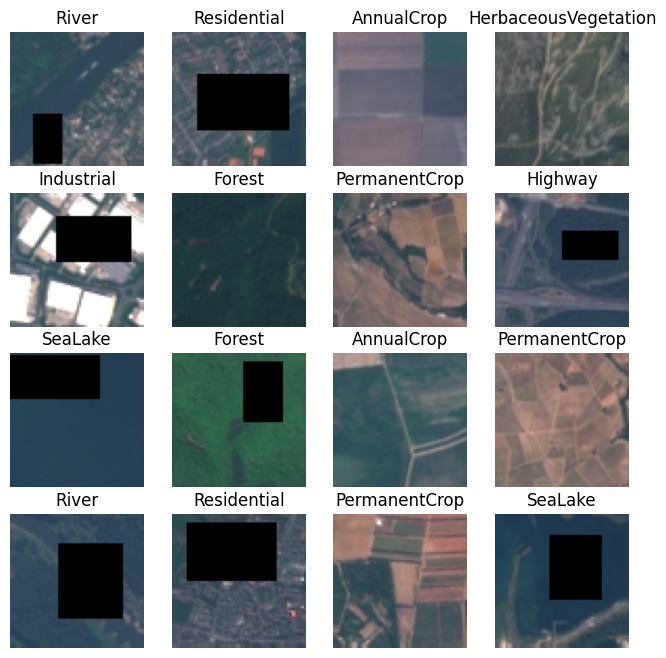

In [17]:
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

print("Image shape:", train_data[0][0].shape)

class_names = data.classes
fig, ax = plt.subplots(4,4,figsize=(8,8))
k = torch.randint(1, 2000, (1,)).item()
for i in range(4):
    for j in range(4):
        image, label = train_data[k]
        ax[i, j].imshow(to_pil_image(image), cmap='grey')
        ax[i,j].axis(False)
        ax[i,j].set_title(class_names[int(label)])
        k += 1
